# Monkey Challenge 
## Pose Estimation

<table class="table">
<thead>
<tr>
<th> Indice </th>
<td> 0 </td>
<td> 1 </td>
<td> 2 </td>
<td> 3 </td>
<td> 4 </td>
<td> 5 </td>
<td> 6 </td>
<td> 7 </td>
<td> 8 </td>
<td> 9 </td>
<td> 10 </td>
<td> 11 </td>
<td> 12 </td>
<td> 13 </td>
<td> 14 </td>
<td> 15 </td>
<td> 16 </td>
</tr>
</thead>

<tbody>
<tr>
<th> Posicion </th>
<td> Right <br>eye </td>
<td> Left <br>eye </td>
<td> Nose </td>
<td> Head </td>
<td> Neck </td>
<td> Right <br>shoulder </td>
<td> Right <br>elbow </td>
<td> Right <br>wrist </td>
<td> Left <br>shoulder </td>
<td> Left <br>elbow </td>
<td> Left <br>wrist </td>
<td> Hip </td>
<td> Right <br>knee </td>
<td> Right <br>ankle </td>
<td> Left <br>knee </td>
<td> Left <br>ankle </td>
<td> Tail </td>
</tr>
</tbody>

</table>

In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import torch.nn as nn

import json
import os
import random

import pandas as pd
import numpy as np

from utils import plot_image_versions, brid_pl, plot_predictions

from preprocessing import adjust_landmarks, Landmarks_Dataset, Rescale, ToTensor
from model import UNet

In [2]:
def set_device():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    return device

def set_seed(seed=None, seed_torch=True):
    if seed is None:
        seed = np.random.choice(2 ** 32)
    random.seed(seed)
    np.random.seed(seed)
    if seed_torch:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

# DEVICE = set_device()

set_seed(775,755)

## Loading data

In [3]:
with open('val_annotation.json', 'r') as f:
  val_annotations = json.load(f)['data']
adjust_landmarks(val_annotations)

In [4]:
val_annotations = pd.DataFrame(val_annotations)
val_annotations['file'] = 'val/'+val_annotations['file']
val_annotations_dict = val_annotations.to_dict('records')

This plot shows the transformation applied to the images.

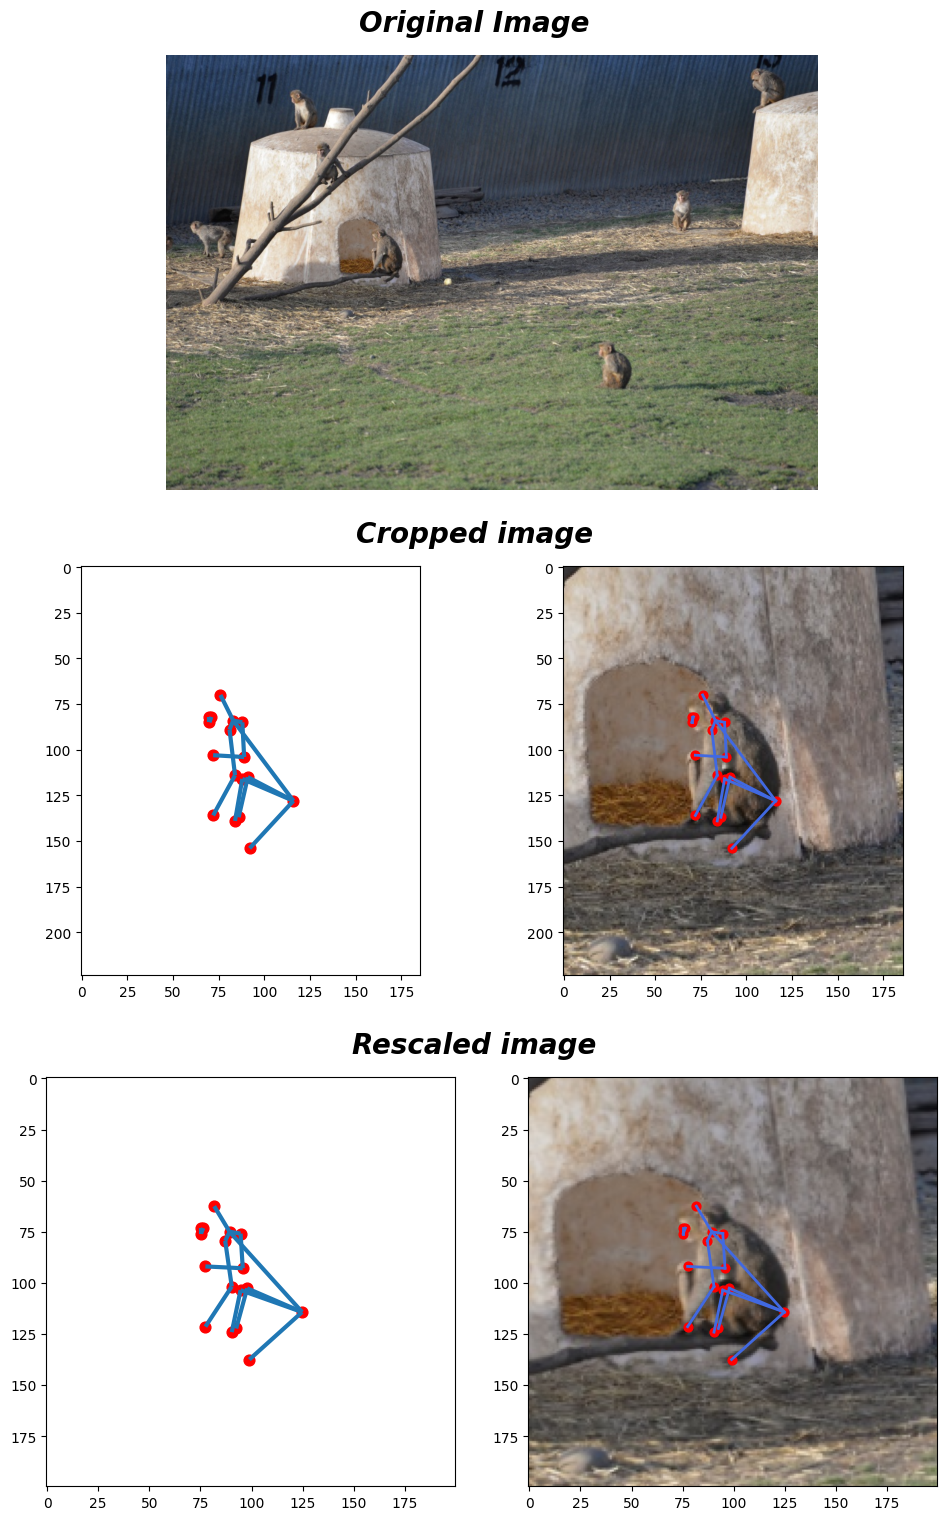

In [5]:
plot_image_versions(val_annotations_dict[0])

In [6]:
val_data = Landmarks_Dataset(val_annotations, transform=transforms.Compose([Rescale(200),
                                                                      ToTensor()]))

## U-NET

In [7]:
# Unet configuration
config = {
    'channels': {
        'c1': 3, 
        'c2': 64,
        'c3': 128,
        'c4': 256,
        'c5': 512,
        'c6': 2
    },
    'FFN': {
        'in': 23328,
        'hl1': 5000,
        'hl2': 500,
        'hl3': 34
    },
    'out':200
}

Instantiating the model and loading the trained weights.

In [8]:
U = UNet(config).to(device = 'cpu')

# loading weights
with open('Uw.pt', 'rb') as f:
    U3  = torch.load(f)
U.load_state_dict(U3)

<All keys matched successfully>

## Inference
Running inference on data not used during training.

In [9]:
im1 = val_data[0]['image'].float()
im2 = val_data[5]['image'].float()

lm1 = val_data[0]['landmarks'].float()
lm2 = val_data[5]['landmarks'].float()

pl = [[im1,lm1],[im2,lm2]]
with torch.no_grad():
    pred = U(torch.stack([im1,im2]).to('cpu'))
plm1 = pred[0].detach().cpu()
plm2 = pred[1].detach().cpu()
predl = [[im1,plm1],[im2,plm2]]

The model performs well, but it still struggles to make accurate predictions with complicated backgrounds in the images.

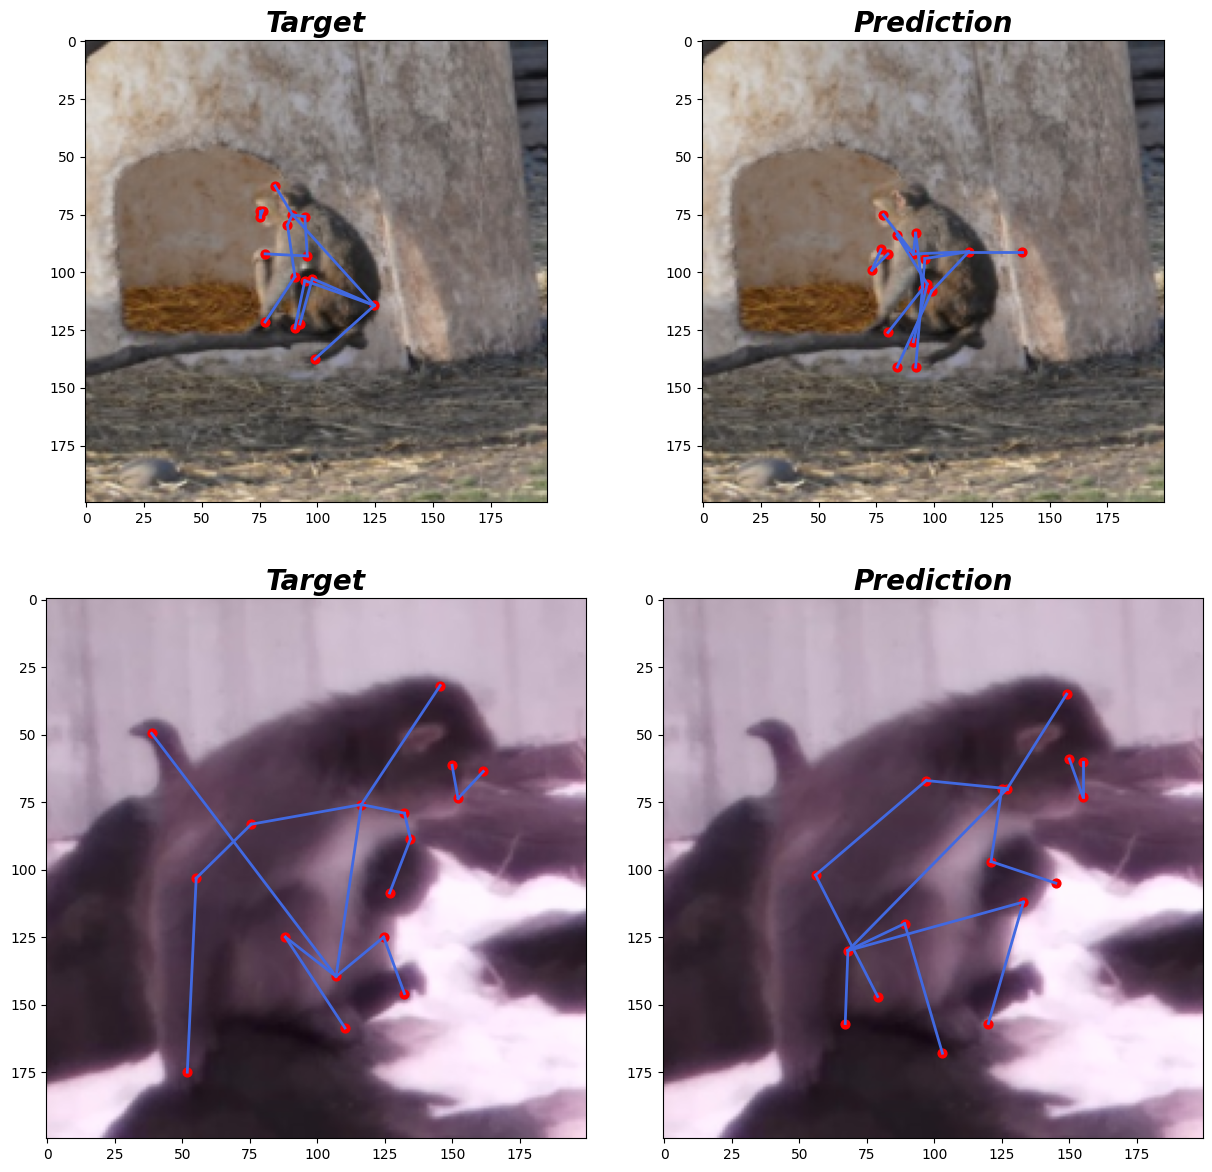

In [10]:
plot_predictions(val_annotations_dict[0], val_annotations_dict[5], np.round(pred[:2].detach().numpy()).astype(int))

## Loss during the training
Metrics obtained with the eval.py script.

In [11]:
import pickle

In [12]:
with open('train_loss.pickle', 'rb') as f:
    train_loss = pickle.load(f)
with open('val_loss.pickle', 'rb') as f:
    val_loss = pickle.load(f)

Based on this plot, we can say that the model is learning well.

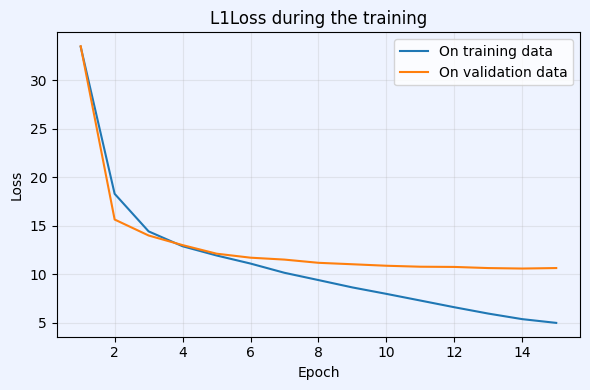

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4), facecolor="#eef3ff")
ax.set_facecolor("#eef3ff")

ax.plot(range(1,16), train_loss, label='On training data')
ax.plot(range(1,16), val_loss, label='On validation data')

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("L1Loss during the training")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()